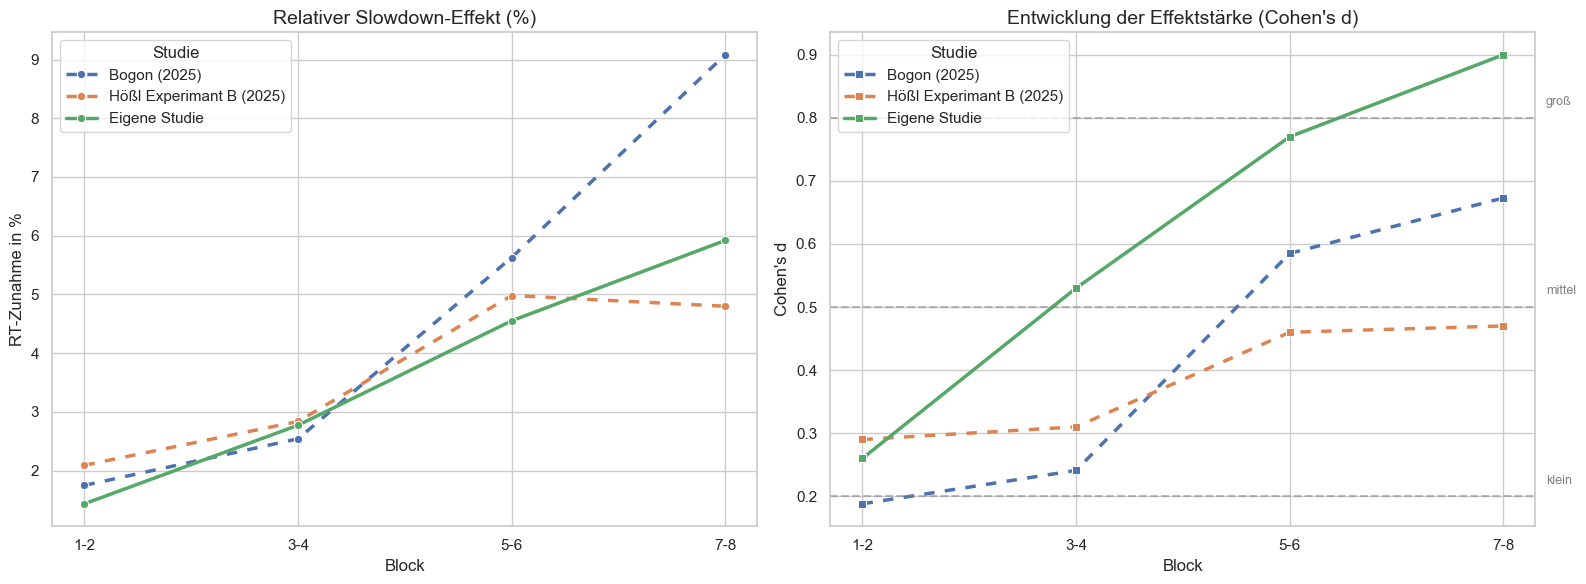

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

data = {
    'Studie': ['Bogon (2025)']*4 + ['Hößl Experimant B (2025)']*4 + ['Eigene Studie']*4,
    'Block': ['1-2', '3-4', '5-6', '7-8'] * 3,
    'NoDelay': [1087, 984, 924, 903, 1148, 1093, 1044, 1042, 630.44, 572.57, 540.56, 527.95],
    'Delay': [1106, 1009, 976, 985, 1172, 1124, 1096, 1092, 639.48, 588.44, 565.16, 559.20],
    'Cohens_d': [0.188, 0.241, 0.585, 0.673, 0.29, 0.31, 0.46, 0.47, 0.26, 0.53, 0.77, 0.90]
}

df = pd.DataFrame(data)
df['Effekt_Prozent'] = ((df['Delay'] - df['NoDelay']) / df['NoDelay']) * 100

line_styles = {
    'Bogon (2025)': (3, 3), 
    'Hößl Experimant B (2025)': (3, 3), 
    'Eigene Studie': ''
}

sns.lineplot(data=df, x='Block', y='Effekt_Prozent', hue='Studie', style='Studie', 
             dashes=line_styles, marker='o', ax=ax1, linewidth=2.5)
ax1.set_title('Relativer Slowdown-Effekt (%)', fontsize=14)
ax1.set_ylabel('RT-Zunahme in %')
ax1.set_xlabel('Block')

sns.lineplot(data=df, x='Block', y='Cohens_d', hue='Studie', style='Studie', 
             dashes=line_styles, marker='s', ax=ax2, linewidth=2.5)
ax2.set_title('Entwicklung der Effektstärke (Cohen\'s d)', fontsize=14)
ax2.set_ylabel('Cohen\'s d')
ax2.set_xlabel('Block')

ax2.axhline(0.2, ls='--', color='gray', alpha=0.5) 
ax2.axhline(0.5, ls='--', color='gray', alpha=0.5) 
ax2.axhline(0.8, ls='--', color='gray', alpha=0.5) 
ax2.text(3.2, 0.22, 'klein', fontsize=9, color='gray')
ax2.text(3.2, 0.52, 'mittel', fontsize=9, color='gray')
ax2.text(3.2, 0.82, 'groß', fontsize=9, color='gray')

plt.tight_layout()
plt.show()